# 1. How can we distinguish between public and privately owned tree canopy in Boston using geospatial data and land use classifications?

**Dataset:** [Tree Canopy Metrics Dataset](https://bostonopendata-boston.opendata.arcgis.com/datasets/boston::canopy-change-assessment-tree-canopy-metrics/about?layer=4)

## Formulas and Definitions for Calculations

[Tree Ordinance 2023](https://www.boston.gov/sites/default/files/file/2024/01/City%20of%20Boston%20Chapter%2014%20of%20the%20Ordinances%20of%202023%20-%20Ordinance%20Establishing%20Protections%20for%20the%20City%20of%20Boston%20Tree%20Canopy%20-%20City%20Clerk%20signature.pdf)

**City of Boston Owned Parcels:** is any parcel of land that is owned by the City of Boston or quasi-agencies. Includes,
* City of Boston
* Boston Water and Sewer Commission
* Boston Housing Authority
* Boston Public Schools
* Boston Redevelopment Authority
* Boston Planning and Development Agency

We included any OWNER that had "City of Boston" + "_", example "Fire Department"

**Non-City of Boston Owned Parcels:** is any parcel of land that is not owned by the City of Boston. Includes state or federally owned parcels. 

**Percentage of Tree Canopy of City of Boston Owned Parcels**  $$\frac{\text{Total Tree canopy existing area classifed as City of Boston Owned}}{\text{Total Tree canopy existing area}}$$


**Percentage of Tree Canopy of Non-City of Boston Owned Parcels** $$\frac{\text{Total Tree canopy existing area classifed as Non-City Owned}}{\text{Total Tree canopy existing area}}$$

**TC_E_A:** Tree canopy existing area. The area of tree canopy present when viewed from above using aerial or satellite imagery, excluding water.

## Citywide Land Audit:
We considered the [Citywide Land Audit](https://data.boston.gov/dataset/city-land-audit-public1) our source of truth for what is owned by the City of Boston. In ArcGIS Pro, we used a series of overlays to recalcualte the area of tree canopy using the following datasets:
* Tree Canopy Polygons 
* Tree Canopy Metrics 
* Citywide Land Audit

The resulting cleaned dataset has instances that represent polygons of tree canopy area. The column 'ownership' defines the ownership of the land that the tree canopy area exists on top of. The column 'area_ft2' represents the area that tree canopy polygon occupies in US Survey Square Feet using the coordinate system NAD 1983 StatePlane Massachusetts FIPS 2001 (US Feet).

In [1]:
import pandas as pd
import numpy as np

# read the classified dataset exported from ArcGIS Pro in
# this table is represented by the 'canopy_polygons_ownership' layer in the 'recalculate_geometry.pptx' file in the ArcGIS files folder 
arcgis_classified_polygons = pd.read_csv('datasets/tree_canopy_polygons_classified_by_ownership.csv')

# contains aggregated tree canopy metrics at the 2019 parcel level 
tree_canopy_metrics = pd.read_csv('datasets/PARCELS_Tree_Canopy_Metrics.csv', dtype={
    'PID': 'string'} )

# load citywide land audit dataset -- considered the authoritative source on what is city owned
# aggregated using 2022 parcels
# reflects 2022 ownership
city_land_audit_public = pd.read_csv("datasets/city_land_audit_public.csv", dtype={
    'Parcel': 'string'})

/Users/rachelyoung/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/rachelyoung/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/var/folders/3k/5zd1hcfd4jv0bjvll1h2r7kr0000gn/T/ipykernel_79567/3012510741.py:6: DtypeWarning: Columns (8,9,10,11,12,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  arcgis_classified_polygons = pd.read_csv('datasets/tree_canopy_polygons_classified_by_ownership.csv')
/var/folders/3k/5zd1hcfd4jv0bjvll1h2r7kr0000gn/T/ipykernel_79567/3012510741.py:9: DtypeWarning: Columns (6,12,14,18,27) have mixed types. Specify dtype option on import or set low_memory=False.


In [2]:
arcgis_classified_polygons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154840 entries, 0 to 154839
Data columns (total 89 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   FID                 64413 non-null   float64
 1   FID_1               154840 non-null  int64  
 2   Shape_Leng          154840 non-null  float64
 3   Shape__Are          154840 non-null  float64
 4   Shape__Len          154840 non-null  float64
 5   ownership           154840 non-null  object 
 6   FID_overlay         64413 non-null   float64
 7   Parcel              15700 non-null   float64
 8   Address             15700 non-null   object 
 9   Owner               15700 non-null   object 
 10  Care_and_C          15700 non-null   object 
 11  Prop_NAME           10527 non-null   object 
 12  GlobalID            15700 non-null   object 
 13  User_Agenc          15676 non-null   object 
 14  Lot_Size_S          15700 non-null   float64
 15  FID_1_overlay       48713 non-null

In [3]:
arcgis_classified_polygons.columns

Index(['FID', 'FID_1', 'Shape_Leng', 'Shape__Are', 'Shape__Len', 'ownership',
       'FID_overlay', 'Parcel', 'Address', 'Owner', 'Care_and_C', 'Prop_NAME',
       'GlobalID', 'User_Agenc', 'Lot_Size_S', 'FID_1_overlay', 'FID_Boston',
       'BOSTON_LAN', 'FID_COB_FY', 'PID', 'CM_ID', 'GIS_ID', 'ST_NUM',
       'ST_NAME', 'ST_NAME_SU', 'UNIT_NUM', 'ZIPCODE', 'LU', 'PTYPE',
       'LOTSIZE', 'MAIL_ADDRE', 'MAIL_CS', 'MAIL_ZIP', 'OWN_OCC', 'GROSS_AREA',
       'BLDG_AREA', 'AV_TOTAL', 'AV_LAND', 'AV_BLDG', 'GROSS_TAX',
       'NUM_FLOORS', 'PID_LONG', 'FULL_ADDRE', 'CITY', 'STArea__',
       'STLength__', 'Shape_STAr', 'Shape_STLe', 'LU_GENERAL', 'TC_ID',
       'Shape_Leng_overlay', 'OBJECTID_1', 'TC_ID_1', 'Total_A', 'Can_A',
       'Grass_A', 'Soil_A', 'Water_A', 'Build_A', 'Road_A', 'Paved_A',
       'Perv_A', 'Imperv_A', 'Can_P', 'Grass_P', 'Soil_P', 'Water_P',
       'Build_P', 'Road_P', 'Paved_P', 'Perv_P', 'Imperv_P', 'OBJECTID_12',
       'TC_ID_12', 'VALUE_0', 'TC_E_A', 'TC_Pv_

# 1. What percentage of Boston's tree canopy is located on public land versus residential parcels?

In [4]:
# keep necessary columns & group by ownership to sum the tree canopy area
agg_tree_canopy_by_ownership = arcgis_classified_polygons[["ownership", "area_ft2"]].groupby("ownership").sum().reset_index()

# calculate the total area of tree canopy on the map
total_tree_canopy = arcgis_classified_polygons["area_ft2"].sum()

# create a new column for total tree canopy
agg_tree_canopy_by_ownership["total_tree_canopy"] = total_tree_canopy

# Calculate Percentage of Tree Canopy
agg_tree_canopy_by_ownership["Percentage of Total Tree Canopy"] = ((agg_tree_canopy_by_ownership["area_ft2"] / agg_tree_canopy_by_ownership["total_tree_canopy"])*100).round(2)

agg_tree_canopy_by_ownership.to_csv("visualization_datasets/agg_tree_canopy_by_ownership.csv", index=False, encoding="utf-8")

agg_tree_canopy_by_ownership

,ownership,area_ft2,total_tree_canopy,Percentage of Total Tree Canopy
0,ROW,4.061967e+07,3.561604e+08,11.40
1,city owned,6.642264e+07,3.561604e+08,18.65
2,non-city owned,2.491181e+08,3.561604e+08,69.95


# 3. What are the trends in tree canopy loss or gain (2014-2019) for public and private areas?

## Data Cleaning

In [5]:
# check that all parcel ID's are 10 digits
city_land_audit_public['pid_length'] = city_land_audit_public['Parcel'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

print(city_land_audit_public['pid_length'].value_counts())

pid_length
10    2939
9        1
Name: count, dtype: int64


In [6]:
# drop the row that has a 9 digit PID code
print(city_land_audit_public[city_land_audit_public['pid_length'] == 9])


      OID_     Parcel                               Address     Owner  \
2920  2921  401862000  320-350 BROOKLINE AV BOSTON MA 02115  Non-City   

     Care_and_Custody                    Prop_NAME  \
2920         Non-City  Ambulance 16 & Paramedic 16   

                                    GlobalID User_Agency  Lot_Size_SF  \
2920  {4F6B0E5E-C36C-4AB1-9641-EED3EE9FD26E}         EMS          NaN   

      Shape_Length  Shape_Area shape_wkt  pid_length  
2920           0.0         0.0       NaN           9  


In [7]:
# drop Parcel == 401862000 because it also does not show in the geospatial map
city_land_audit_public = city_land_audit_public[city_land_audit_public['Parcel'] != '401862000']
print(len(city_land_audit_public)) #check it was dropped. should return 2939

2939


In [8]:
#find all unique values of parcel ID's in the land audit and the tree canopy metrics datasets
land_audit_pid = city_land_audit_public["Parcel"].astype(str).str.strip().unique().tolist()
tree_metrics = tree_canopy_metrics["PID"].astype(str).str.strip().unique().tolist()

# find the number of parcel ID's that are in the land audit from 2022, but are not in the tree canopy metrics dataset
missing_parcels_from_tree_canopy_metrics = [item for item in land_audit_pid if item not in tree_metrics]

print("There are", len(missing_parcels_from_tree_canopy_metrics), "parcel ID's missing from the tree_canopy_metrics dataset that are considered public in the city wide land audit. This is most likely due to changed parcel mapping from 2019 to 2022.")

There are 33 parcel ID's missing from the tree_canopy_metrics dataset that are considered public in the city wide land audit. This is most likely due to changed parcel mapping from 2019 to 2022.


In [9]:
missing_parcels_from_tree_canopy_metrics 

['1600003000',
 '1600004000',
 '1600008001',
 '1600007001',
 '1303393000',
 '1303394000',
 '0303027000',
 '1604329000',
 '0602670001',
 '0105396000',
 '1200283000',
 '1701287010',
 '0202005002',
 '0103711008',
 '0303687010',
 '0502497000',
 '0100433000',
 '1101208050',
 '1101208030',
 '1101208040',
 '1101208020',
 '1101208010',
 '2009010010',
 '0700538020',
 '0700539005',
 '0902643010',
 '0902643050',
 '0000000001',
 '0000000004',
 '0000000003',
 '0000000005',
 '0000000006',
 '0000000007']

## Analysis

In [10]:
# list of parcel ID's considered publicly owned 
public_pids = city_land_audit_public["Parcel"].astype(str).str.strip().unique().tolist()

In [11]:
# load in the tree canopy change dataset
parcel_canopy_change_metrics = pd.read_csv("datasets/PARCELS_Tree_Canopy_Change_Metrics.csv", dtype={
    'PID': 'string'})

# the polygon representing all null data has a " " for the PID
# Replace the PID == " " as 'ROW', since it represents all roads and sidewalks in Boston
parcel_canopy_change_metrics.loc[parcel_canopy_change_metrics["PID"] == " ", "PID"] = "ROW"

# apply the classification method to the PID column
# column 'ownership' classifies parcels as 'city owned', 'non-city owned', or 'ROW'
parcel_canopy_change_metrics["ownership"] = parcel_canopy_change_metrics["PID"].apply(lambda x: 
                                "city owned" if x in public_pids
                                 else "ROW" if x == "ROW" 
                                 else "non-city owned")

parcel_canopy_change_metrics

/var/folders/3k/5zd1hcfd4jv0bjvll1h2r7kr0000gn/T/ipykernel_79567/2666836123.py:2: DtypeWarning: Columns (6,12,14,18,27) have mixed types. Specify dtype option on import or set low_memory=False.
  parcel_canopy_change_metrics = pd.read_csv("datasets/PARCELS_Tree_Canopy_Change_Metrics.csv", dtype={


,FID,FID_Boston,BOSTON_LAN,FID_COB_FY,PID,CM_ID,GIS_ID,OWNER,ST_NUM,ST_NAME,...,TreeCanopy,TreeCano_1,Change_Are,Change_Per,TreeCano_2,TreeCano_3,Change_P_1,Shape__Area,Shape__Length,ownership
0,1,1,1,-1,ROW,,,,,,...,3.986780e+07,4.087817e+07,1.010378e+06,2.534321,18.240958,18.703243,0.462284,2.244137e+08,8.914611e+06,ROW
1,2,1,1,1,0100001000,,0100001000,PASCUCCI CARLO,104 A 104,PUTNAM,...,7.893076e-01,5.009830e+00,4.220522e+00,534.711924,0.063840,0.405203,0.341363,1.233845e+03,1.594376e+02,non-city owned
2,3,1,1,2,0100002000,,0100002000,ATANASOV DANIEL,197,LEXINGTON,...,2.350375e+00,0.000000e+00,-2.350375e+00,-100.000000,0.202640,0.000000,-0.202640,1.161436e+03,1.566642e+02,non-city owned
3,4,1,1,3,0100003000,,0100003000,CHEVARRIA ANA S,199,LEXINGTON,...,2.794576e+01,7.557041e+00,-2.038872e+01,-72.958186,2.440145,0.659860,-1.780286,1.145411e+03,1.558082e+02,non-city owned
4,5,1,1,4,0100004000,,0100004000,"MADDALENI JAMES E, TS",201,LEXINGTON,...,9.597758e-01,5.904437e+00,4.944661e+00,515.189183,0.080560,0.495599,0.415038,1.192610e+03,1.571514e+02,non-city owned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173870,173871,1,1,17020,0300452750,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173871,173872,1,1,17021,0300452752,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173872,173873,1,1,17022,0300452754,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173873,173874,1,1,17023,0300452756,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned


In [12]:
# Calculate number of parcels the are in each classification
parcel_canopy_change_metrics["ownership"].value_counts()

ownership
non-city owned    170990
city owned          2884
ROW                    1
Name: count, dtype: int64

### Column Definitions:
* TreeCanopy= 2014 total canopy area (baseline)
* TreeCano_1 = 2019 total canopy area
* Gain = Tree canopy area gain 
* Loss = Tree canopy area loss 

In [13]:
# Find the difference between 2019 total canopy area and 2014 total canopy area for each parcel 
parcel_canopy_change_metrics["diff"] = parcel_canopy_change_metrics['TreeCano_1'] - parcel_canopy_change_metrics['TreeCanopy'] 

# Find the difference between tree canopy gain and loss for each parcel
parcel_canopy_change_metrics["diff_g_l"] = parcel_canopy_change_metrics['Gain'] - parcel_canopy_change_metrics['Loss'] 

#print results 
parcel_canopy_change_metrics[["Gain", "Loss","No_Change", 'TreeCanopy', 'TreeCano_1', 'diff', "diff_g_l"]]

,Gain,Loss,No_Change,TreeCanopy,TreeCano_1,diff,diff_g_l
0,7.443209e+06,6.432831e+06,3.343496e+07,3.986780e+07,4.087817e+07,1.010378e+06,1.010378e+06
1,4.220522e+00,0.000000e+00,7.893076e-01,7.893076e-01,5.009830e+00,4.220522e+00,4.220522e+00
2,0.000000e+00,2.350375e+00,0.000000e+00,2.350375e+00,0.000000e+00,-2.350375e+00,-2.350375e+00
3,3.760469e+00,2.414919e+01,3.796573e+00,2.794576e+01,7.557041e+00,-2.038872e+01,-2.038872e+01
4,4.944661e+00,0.000000e+00,9.597758e-01,9.597758e-01,5.904437e+00,4.944661e+00,4.944661e+00
...,...,...,...,...,...,...,...
173870,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
173871,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
173872,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
173873,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [14]:
#aggregate tree canopy gain and loss by ownership
gain_loss_agg = parcel_canopy_change_metrics.groupby("ownership")[["Gain", "Loss",'TreeCanopy', 'TreeCano_1', "diff_g_l"]].sum().reset_index()

#rename the columns 
gain_loss_agg = gain_loss_agg.rename(columns={"TreeCanopy": "2014 Tree Canopy", "TreeCano_1": "2019 Tree Canopy"})

#calculate the percentage difference in tree canopy from 2014 to 2019
gain_loss_agg["Percent_Diff"] = ((gain_loss_agg["2019 Tree Canopy"] -  gain_loss_agg["2014 Tree Canopy"])/gain_loss_agg["2014 Tree Canopy"]) *100

# #export dataset for visualization
gain_loss_agg.to_csv("visualization_datasets/gain_loss_agg.csv", index=False, encoding="utf-8")
gain_loss_agg

,ownership,Gain,Loss,2014 Tree Canopy,2019 Tree Canopy,diff_g_l,Percent_Diff
0,ROW,7.443209e+06,6.432831e+06,3.986780e+07,4.087817e+07,1.010378e+06,2.534321
1,city owned,5.574940e+06,4.144158e+06,6.565736e+07,6.708814e+07,1.430782e+06,2.179165
2,non-city owned,2.705524e+07,2.924864e+07,2.523491e+08,2.501557e+08,-2.193402e+06,-0.869194


# 4. Which areas have the highest potential for expanding tree canopy, and are they public or private spaces?

## Column Definitions
* TC_PV_A= Possible vegetation area. Grass or shrub area that is theoretically available for
the establishment of tree canopy.
* TC_Pi_A= Possible impervious area. Asphalt or concrete surfaces or bare soil, excluding
roads and buildings, that are theoretically available for the establishment of tree canopy.
* TC_P_A= Possible area. Area theoretically available for establishment of tree canopy.
* TC_Land_A = Land area. Land area excluding water bodies.

In [15]:
# apply the classification method to the PID's column
# column 'ownership' classifies parcels as 'city owned', 'non-city owned', or 'ROW'
tree_canopy_metrics["ownership"] = tree_canopy_metrics["PID"].apply(lambda x: 
                                "city owned" if x in public_pids
                                 else "ROW" if x == " " 
                                 else "non-city owned")

tree_canopy_metrics

,FID,FID_Boston,BOSTON_LAN,FID_COB_FY,PID,CM_ID,GIS_ID,OWNER,ST_NUM,ST_NAME,...,TC_Land_A,TC_Pi_A,TC_P_A,TC_E_P,TC_Pv_P,TC_P_P,TC_Pi_P,Shape__Area,Shape__Length,ownership
0,1,1,1,-1,,,,,,,...,218739022,38429015,44146608,18.670309,2.613888,20.182319,17.568431,2.244137e+08,8.914611e+06,ROW
1,2,1,1,1,0100001000,,0100001000,PASCUCCI CARLO,104 A 104,PUTNAM,...,1237,13,13,0.404204,0.000000,1.050930,1.050930,1.233845e+03,1.594376e+02,non-city owned
2,3,1,1,2,0100002000,,0100002000,ATANASOV DANIEL,197,LEXINGTON,...,1162,242,242,0.000000,0.000000,20.826162,20.826162,1.161436e+03,1.566642e+02,non-city owned
3,4,1,1,3,0100003000,,0100003000,CHEVARRIA ANA S,199,LEXINGTON,...,1144,211,212,0.699301,0.087413,18.531469,18.444056,1.145411e+03,1.558082e+02,non-city owned
4,5,1,1,4,0100004000,,0100004000,"MADDALENI JAMES E, TS",201,LEXINGTON,...,1191,102,208,0.587741,8.900084,17.464316,8.564232,1.192610e+03,1.571514e+02,non-city owned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173870,173871,1,1,17020,0300452750,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0,0,0,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173871,173872,1,1,17021,0300452752,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0,0,0,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173872,173873,1,1,17022,0300452754,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0,0,0,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned
173873,173874,1,1,17023,0300452756,0300450000,300450000,WHITTIER PLACE CONDOMINIUM,6 -8,WHITTIER,...,0,0,0,0.000000,0.000000,0.000000,0.000000,2.214873e+05,1.990351e+03,non-city owned


In [16]:
potential_expansion = tree_canopy_metrics.groupby("ownership")[["TC_Pv_A", "TC_Pi_A",'TC_P_A', "TC_Land_A"]].sum().reset_index()

potential_expansion["Percentage Possible Vegetation Area"] = potential_expansion["TC_Pv_A"]/potential_expansion["TC_Land_A"]

potential_expansion["Percentage Possible Impervious Area"] = potential_expansion["TC_Pi_A"]/potential_expansion["TC_Land_A"]

potential_expansion["Percentage Possible Tree Canopy Area"] = round((potential_expansion["TC_P_A"]/potential_expansion["TC_Land_A"])*100)

potential_expansion[["ownership", "Percentage Possible Tree Canopy Area"]]

,ownership,Percentage Possible Tree Canopy Area
0,ROW,20.0
1,city owned,48.0
2,non-city owned,41.0


## By Neighborhood

###  Data Cleaning

In [39]:
# Read in the data exported from ArcGIS File "ArcGIS Files/recalculated_geometry.ppkx" in the layer 'pids_by_neighborhood'
# Lists all parcel ids in the dataset by which neighborhood they have the greatest spatial overlap with 
import zipfile
import pandas as pd

zip_path = 'datasets/pids_by_neighborhood.csv.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    # List files in the zip
    print(z.namelist())

    # Read the first file directly into pandas
    with z.open(z.namelist()[0]) as f:
        pids_by_neighborhood = pd.read_csv(f, dtype={
    'PID': 'string'})

neighborhoods_pids = pids_by_neighborhood[["PID", "Name"]]

['pids_by_neighborhood.csv', '__MACOSX/._pids_by_neighborhood.csv']


/var/folders/3k/5zd1hcfd4jv0bjvll1h2r7kr0000gn/T/ipykernel_79567/3953511152.py:14: DtypeWarning: Columns (8,14,16,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  pids_by_neighborhood = pd.read_csv(f, dtype={


In [40]:
# Check if neighborhoods_pids has duplicate PIDs
duplicates = neighborhoods_pids['PID'].duplicated(keep=False)
print(neighborhoods_pids[duplicates])

# Drop duplicates
neighborhoods_pids_unique = neighborhoods_pids.drop_duplicates(subset='PID')

               PID            Name
1376    0101516000     East Boston
1378    0101516005     East Boston
1810    0101976000     East Boston
1811    0101977000     East Boston
1823    0101992000     East Boston
...            ...             ...
163855  0304870410  Central Boston
163856  0304870412  Central Boston
163857  0304870414  Central Boston
163858  0304870416  Central Boston
163859  0304885000  Central Boston

[3520 rows x 2 columns]


In [41]:
neighborhoods_pids.info()

# Search for nulls that were not caught by the spatial join
# these 3 parcels were outside the boundary of what the neighborhoods map included as polygons
neighborhoods_pids[neighborhoods_pids['Name'].isnull()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173875 entries, 0 to 173874
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   PID     173875 non-null  string
 1   Name    173872 non-null  object
dtypes: object(1), string(1)
memory usage: 2.7+ MB


,PID,Name
7407,0201831000,NaN
7408,0201831001,NaN
9572,0302951010,NaN


In [42]:
# these were the parcel ids that were supposed to be in Charlestown
pids_to_update = ["0201831000", "0201831001"]  

# Update 'Name' to 'Charlestown' for the specified PIDs
neighborhoods_pids_unique.loc[
    neighborhoods_pids_unique['PID'].isin(pids_to_update),
    'Name'
] = 'Charlestown'



In [43]:
#create a copy of tree canopy metrics 
cleaned_tree_metrics_parcels = tree_canopy_metrics.copy()

# drop nulls -- have no neighborhood
# It's in an area that is between neighborhoods, with no clear classification
cleaned_tree_metrics_parcels  = cleaned_tree_metrics_parcels [
    cleaned_tree_metrics_parcels['PID'] != "0302951010"
]
# remove row representing right of way data
cleaned_tree_metrics_parcels  = cleaned_tree_metrics_parcels [
    cleaned_tree_metrics_parcels['PID'] != "ROW"
]

In [44]:
# classifies each parcel in tree canopy metrics with its neighborhood
neighborhoods_tree_canopy_potential  = cleaned_tree_metrics_parcels.merge(
    neighborhoods_pids_unique, 
    on = "PID",
    how = "left") 



In [45]:
neighborhoods_tree_canopy_potential[["Name", "ownership", "TC_P_A"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173874 entries, 0 to 173873
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Name       173873 non-null  object
 1   ownership  173874 non-null  object
 2   TC_P_A     173874 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.0+ MB


In [24]:
# groups parcels by their neighborhood and sum their potential tree canopy and their land area 
# represents total neighborhood metrics
potential_tree_canopy_by_neighborhood = neighborhoods_tree_canopy_potential.groupby("Name")[["TC_P_A", "TC_Land_A"]].sum().reset_index().sort_values(by='TC_P_A', ascending =False)

# rename the columns 
potential_tree_canopy_by_neighborhood = potential_tree_canopy_by_neighborhood.rename(columns={"TC_P_A": "Total_Neighborhood_TC_P_A", "TC_Land_A": "Total_Neighborhood_TC_Land_A"}) 

In [25]:
# Group parcels by their neighborhood and ownership and sum existing and potential tree canopy 
# represents ownership breakdown 
potential_T_C_by_ownership = neighborhoods_tree_canopy_potential.groupby(["Name", "ownership"])[["TC_E_A", "TC_P_A"]].sum().reset_index(level='Name').reset_index()

# join the metrics describing potential canopy at the neighborhood level and at the broken down ownership level
potential_TC_A_by_neighborhood_and_ownership = potential_T_C_by_ownership.merge(
    potential_tree_canopy_by_neighborhood,
    on = "Name",
    how = "left"
)

#potential_TC_A_by_neighborhood_and_ownership["percentage_of_total_potential_area"] = round((potential_TC_A_by_neighborhood_and_ownership["TC_P_A"]/potential_TC_A_by_neighborhood_and_ownership["Total_Neighborhood_TC_P_A"])*100)

potential_TC_A_by_neighborhood_and_ownership["percentage_of_land_suitable_for_canopy"] = round((potential_TC_A_by_neighborhood_and_ownership["TC_P_A"]/potential_TC_A_by_neighborhood_and_ownership["Total_Neighborhood_TC_Land_A"])*100, 2)

#potential_TC_A_by_neighborhood_and_ownership["percentage_of_land_with_existing_TC"] = round((potential_TC_A_by_neighborhood_and_ownership["TC_E_A"]/potential_TC_A_by_neighborhood_and_ownership["Total_Neighborhood_TC_Land_A"])*100, 2)

potential_TC_A_by_neighborhood_and_ownership["percentage_of_entire_neighborhood_suitable_for_canopy"] = round((potential_TC_A_by_neighborhood_and_ownership["Total_Neighborhood_TC_P_A"]/potential_TC_A_by_neighborhood_and_ownership["Total_Neighborhood_TC_Land_A"])*100, 2)

In [26]:
# sort by neighborhood with the greatest area for tree canopy 
potential_TC_A_by_neighborhood_and_ownership = potential_TC_A_by_neighborhood_and_ownership.sort_values(by = "Total_Neighborhood_TC_P_A", ascending =False)

#export for visualization 
potential_TC_A_by_neighborhood_and_ownership.to_csv("visualization_datasets/potential_TC_A_by_neighborhood_and_ownership.csv", index=False, encoding="utf-8")

In [27]:
potential_TC_A_by_neighborhood_and_ownership

,ownership,Name,TC_E_A,TC_P_A,Total_Neighborhood_TC_P_A,Total_Neighborhood_TC_Land_A,percentage_of_land_suitable_for_canopy,percentage_of_entire_neighborhood_suitable_for_canopy
8,city owned,Dorchester,16544915,15297452,82525985,186732008,8.19,44.19
9,non-city owned,Dorchester,33749109,67228533,82525985,186732008,36.00,44.19
11,non-city owned,East Boston,7084978,55788521,58959491,118721750,46.99,49.66
10,city owned,East Boston,922385,3170970,58959491,118721750,2.67,49.66
33,non-city owned,West Roxbury,47641814,46631150,52856180,124815114,37.36,42.35
32,city owned,West Roxbury,5069360,6225030,52856180,124815114,4.99,42.35
16,city owned,Hyde Park,7107050,7484131,42206419,114986185,6.51,36.71
17,non-city owned,Hyde Park,46326215,34722288,42206419,114986185,30.20,36.71
0,city owned,Allston-Brighton,2211867,3590531,41874906,99302398,3.62,42.17
1,non-city owned,Allston-Brighton,21810063,38284375,41874906,99302398,38.55,42.17


# Additional Question: What percentage of each Neighborhood is public vs private canopy?



In [38]:
# read in dataset that was created using ArcGIS Pro
# classified all parcels of polygons to be in the neighborhood that the polygon has the greatest overlap with
# Corresponds to layer named "tree_canopy_polygons_by_neighborhood" in "ArcGIS Files/recalculated_geometry.ppkx"
import zipfile
import pandas as pd

zip_path = 'datasets/tree_canopy_polygons_by_neighborhoods.csv.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    # List files in the zip
    print(z.namelist())

    # Read the first file directly into pandas
    with z.open(z.namelist()[0]) as f:
        neighborhoods = pd.read_csv(f,dtype={
    'PID': 'string'})

neighborhoods[["Name", "PID", "ownership", "area_ft2"]]



['tree_canopy_polygons_by_neighborhoods.csv', '__MACOSX/._tree_canopy_polygons_by_neighborhoods.csv']


/var/folders/3k/5zd1hcfd4jv0bjvll1h2r7kr0000gn/T/ipykernel_79567/2227918327.py:15: DtypeWarning: Columns (10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  neighborhoods = pd.read_csv(f,dtype={


,Name,PID,ownership,area_ft2
0,Jamaica Plain,<NA>,city owned,562.997748
1,Roxbury,<NA>,city owned,255.998976
2,Charlestown,<NA>,city owned,404.781500
3,Dorchester,<NA>,city owned,2440.842397
4,Dorchester,<NA>,city owned,194.499222
...,...,...,...,...
154835,Dorchester,<NA>,non-city owned,1511.508062
154836,Roslindale,<NA>,non-city owned,387.177696
154837,Jamaica Plain,<NA>,non-city owned,77921.878651
154838,Roslindale,<NA>,non-city owned,9361.902170


In [29]:
agg_area_by_neighborhood = neighborhoods.groupby(["Name","ownership"])["area_ft2"].sum().reset_index(level='Name').reset_index()

#rename the area column to be "tree_canopy_area"
agg_area_by_neighborhood = agg_area_by_neighborhood.rename(columns={'area_ft2': 'tree_canopy_area'})

In [30]:
#load in tree canopy metrics 
neighborhoods_tree_canopy_metrics = pd.read_csv("datasets/Neighborhood_Tree_Canopy_Metrics.csv")

# TC_Land_A = Land area. Land area excluding water bodies. Standardize because some neighborhoods are much bigger than others
add_total_land_area = agg_area_by_neighborhood .merge(
    neighborhoods_tree_canopy_metrics[["Name", "TC_Land_A"]],  
    on='Name',                                 
    how='left')    

# calculate total tree canopy of each neighborhood
agg_total_canopy_by_neighborhood = neighborhoods.groupby(["Name"])["area_ft2"].sum().reset_index()

#rename the area column to be "total_neighborhood_tree_canopy"
agg_total_canopy_by_neighborhood = agg_total_canopy_by_neighborhood.rename(columns={'area_ft2': 'total_neighborhood_tree_canopy'})

# add total neighborhood tree canopy as a column
# TC_Land_A = Land area. Land area excluding water bodies. Standardize because some neighborhoods are much bigger than others
add_total_tree_canopy_area = add_total_land_area.merge(
    agg_total_canopy_by_neighborhood,  
    on='Name',                                 
    how='left')    


add_total_tree_canopy_area


,ownership,Name,tree_canopy_area,TC_Land_A,total_neighborhood_tree_canopy
0,ROW,Allston-Brighton,3.311113e+06,119344898,2.725649e+07
1,city owned,Allston-Brighton,2.153600e+06,119344898,2.725649e+07
2,non-city owned,Allston-Brighton,2.179178e+07,119344898,2.725649e+07
3,ROW,Back Bay/Beacon Hill,1.584370e+06,25617982,5.427028e+06
4,city owned,Back Bay/Beacon Hill,1.752344e+06,25617982,5.427028e+06
5,non-city owned,Back Bay/Beacon Hill,2.090314e+06,25617982,5.427028e+06
6,ROW,Central Boston,7.661159e+05,35917534,3.200696e+06
7,city owned,Central Boston,5.395836e+05,35917534,3.200696e+06
8,non-city owned,Central Boston,1.894996e+06,35917534,3.200696e+06
9,ROW,Charlestown,1.157410e+06,36952901,4.438874e+06


In [31]:
# calculate percentages that standardized by total tree canopy and total land area
add_total_tree_canopy_area["percentage_of_total_neighborhood_tree_canopy"] = round((add_total_tree_canopy_area["tree_canopy_area"]/add_total_tree_canopy_area["total_neighborhood_tree_canopy"])*100)

add_total_tree_canopy_area["percentage_of_total_neighborhood_land_area"] = round((add_total_tree_canopy_area["tree_canopy_area"]/add_total_tree_canopy_area["TC_Land_A"])*100)

In [32]:
city_owned = add_total_tree_canopy_area[add_total_tree_canopy_area['ownership'] == 'city owned']

# Sort city-owned neighborhoods by percentage_of_total_tree_canopy, descending
city_owned_sorted = city_owned.sort_values(by="percentage_of_total_neighborhood_land_area", ascending=False)

# Display only the columns you want
result = city_owned_sorted[['ownership', 'Name', 'tree_canopy_area', 'TC_Land_A',
                            'total_neighborhood_tree_canopy', "percentage_of_total_neighborhood_land_area"]]

result.sort_values(by = "percentage_of_total_neighborhood_land_area", ascending =False)

,ownership,Name,tree_canopy_area,TC_Land_A,total_neighborhood_tree_canopy,percentage_of_total_neighborhood_land_area
22,city owned,Harbor Islands,4.881158e+06,33414793,8.748219e+06,15.0
28,city owned,Jamaica Plain,1.406406e+07,110063490,4.670391e+07,13.0
40,city owned,Roxbury,6.309881e+06,74109027,1.944562e+07,9.0
34,city owned,Mission Hill,1.201291e+06,15188045,3.985133e+06,8.0
37,city owned,Roslindale,5.007054e+06,73086124,2.347272e+07,7.0
19,city owned,Fenway/Longwood,2.122656e+06,31950453,5.747109e+06,7.0
4,city owned,Back Bay/Beacon Hill,1.752344e+06,25617982,5.427028e+06,7.0
31,city owned,Mattapan,3.627624e+06,58450171,2.014088e+07,6.0
25,city owned,Hyde Park,7.044038e+06,125584936,5.850938e+07,6.0
13,city owned,Dorchester,8.427804e+06,213645571,4.747711e+07,4.0


In [33]:
add_total_tree_canopy_area

,ownership,Name,tree_canopy_area,TC_Land_A,total_neighborhood_tree_canopy,percentage_of_total_neighborhood_tree_canopy,percentage_of_total_neighborhood_land_area
0,ROW,Allston-Brighton,3.311113e+06,119344898,2.725649e+07,12.0,3.0
1,city owned,Allston-Brighton,2.153600e+06,119344898,2.725649e+07,8.0,2.0
2,non-city owned,Allston-Brighton,2.179178e+07,119344898,2.725649e+07,80.0,18.0
3,ROW,Back Bay/Beacon Hill,1.584370e+06,25617982,5.427028e+06,29.0,6.0
4,city owned,Back Bay/Beacon Hill,1.752344e+06,25617982,5.427028e+06,32.0,7.0
5,non-city owned,Back Bay/Beacon Hill,2.090314e+06,25617982,5.427028e+06,39.0,8.0
6,ROW,Central Boston,7.661159e+05,35917534,3.200696e+06,24.0,2.0
7,city owned,Central Boston,5.395836e+05,35917534,3.200696e+06,17.0,2.0
8,non-city owned,Central Boston,1.894996e+06,35917534,3.200696e+06,59.0,5.0
9,ROW,Charlestown,1.157410e+06,36952901,4.438874e+06,26.0,3.0


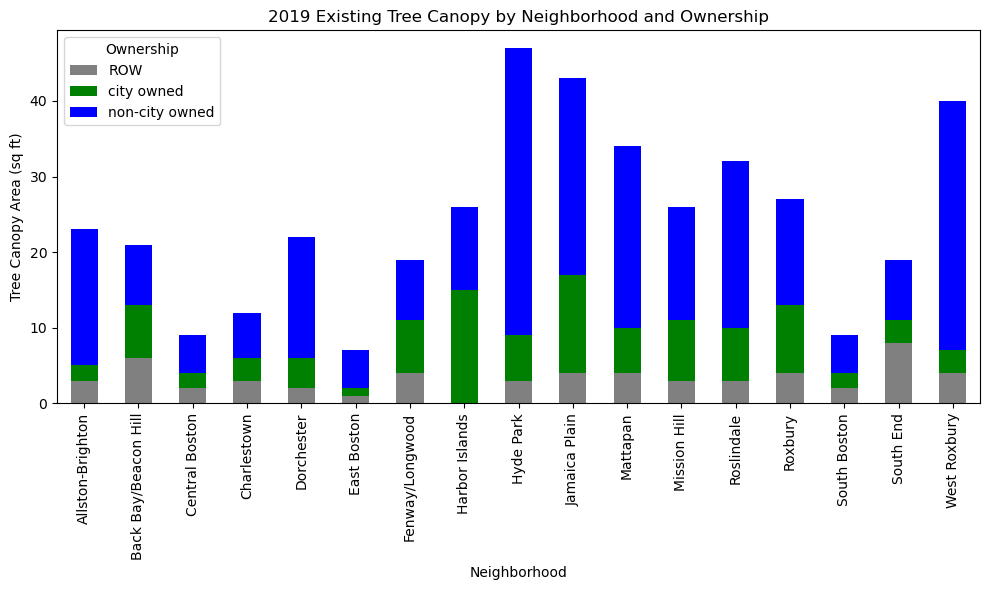

In [34]:
import matplotlib.pyplot as plt
# Pivot the data for stacked bar
pivot = add_total_tree_canopy_area.pivot(index='Name', columns='ownership', values="percentage_of_total_neighborhood_land_area").fillna(0)

# Plot
pivot.plot(kind='bar', stacked=True, figsize=(10,6), color=['grey','green', 'blue'])

plt.title('2019 Existing Tree Canopy by Neighborhood and Ownership')
plt.ylabel('Tree Canopy Area (sq ft)')
plt.xlabel('Neighborhood')
plt.legend(title='Ownership')
plt.tight_layout()
plt.show()

In [35]:
pivot.reset_index().to_csv("visualization_datasets/TC_E_A_by_neighborhood_and_ownership.csv", index=False, encoding="utf-8")

# Additional Question: Who are the most common owners of "Non-City" owned parcels?

In [36]:
# filter parcels to non-city owned parcels
non_city_parcels = tree_canopy_metrics[tree_canopy_metrics['ownership'] == "non-city owned"]

# filter to parcels that are tax exempt
# have 'PTYPE' that start with 9
# Assume these parcels are publicly owned 
tax_exempt = non_city_parcels[non_city_parcels['PTYPE'].astype(str).str.startswith('9')]

# Find owners of who own the most parcels of land 
tax_exempt_owners = pd.DataFrame(tax_exempt["OWNER"].value_counts()).reset_index()

tax_exempt_owners.head(20)

,OWNER,count
0,COMMONWEALTH OF MASS,226
1,COMMWLTH OF MASS,144
2,CITY OF BOSTON,144
3,MASS BAY TRANSPORTATION AUTH,130
4,MASS BAY TRANSP AUTH,97
5,MARRIOTT OWNERSHIP RESORTS,84
6,BOSTON UNIVERSITY TRSTS OF,81
7,DUDLEY NEIGHBORS INC,80
8,BOSTON HOUSING AUTHORITY,80
9,MASS PORT AUTHORITY,76


In [37]:
# Create a pivot table to count parcels by OWNER and LU_GENERAL category
pivot_table = pd.pivot_table(
    tax_exempt,
    index="OWNER",
    columns="LU_GENERAL",
    values="PID",
    aggfunc="count",
    fill_value=0  
)

pivot_table["TOTAL"] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values(by="TOTAL", ascending=False)

pivot_table.head(10)

LU_GENERAL,Institutional,Residential,TOTAL
OWNER,,,
COMMONWEALTH OF MASS,220,6,226
COMMWLTH OF MASS,144,0,144
CITY OF BOSTON,144,0,144
MASS BAY TRANSPORTATION AUTH,130,0,130
MASS BAY TRANSP AUTH,97,0,97
MARRIOTT OWNERSHIP RESORTS,84,0,84
BOSTON UNIVERSITY TRSTS OF,81,0,81
BOSTON HOUSING AUTHORITY,80,0,80
DUDLEY NEIGHBORS INC,0,80,80
